# notebook 05 - task 2.3: error analysis and cluster quality reflection

**assignment requirement:** identify the pair of cluster labels your classifier
confuses most often, then answer:
1. which two clusters are most often confused, and in which direction?
2. what is the main cause of this confusion? (quantitative or textual evidence)
3. what does this confusion tell you about the quality of your clustering?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from scipy.stats import mannwhitneyu

import sys
sys.path.append("..")
from src.config.settings import (
    FIG_DIR,
    EFFORT_DIMENSIONS,
    EFFORT_DIM_LABELS,
    CLUSTER_PALETTE,
    AGENT_ORDER,
    AGENT_DISPLAY,
    RANDOM_STATE,
    TEST_SIZE,
    TFIDF_MAX_FEATURES,
    TFIDF_NGRAM_RANGE,
    TFIDF_MIN_DF,
    TFIDF_MAX_DF,
)
from src.utils.helper import (
    load_clustered,
    prepare_text_data,
    preprocess_text,
    CLUSTER_LABEL_MAP,
)

FIG_DIR.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_style("whitegrid")

## 1. reproduce classification results

In [2]:
df = load_clustered()
df_text = prepare_text_data(df)
df_text["body_clean"] = preprocess_text(df_text["body"])
df_text.head()

,id,number,title,body,agent,user_id,user,state,created_at,closed_at,merged_at,repo_id,repo_url,html_url,is_agentic,n_formal_reviews,has_review_data,n_review_comments,time_to_merge_hours,total_additions,total_deletions,total_files_changed,total_churn,n_unique_reviewers,churn_per_review_cycle,task_type,cluster,pca1,pca2,time_to_merge_hours_log,n_formal_reviews_log,n_review_comments_log,n_unique_reviewers_log,churn_per_review_cycle_log,cluster_str,body_clean
0,3265118634,2,ファイルパス参照を相対パスに統一し、doc/からdocs/に統一,## 背景\n\n現在、本プロジェクトにおいて以下のパス構成の不整合が生じています：\n\n...,Claude_Code,61827001,cm-kojimat,closed,2025-07-26 04:56:55+00:00,2025-07-26T22:12:24Z,2025-07-26 22:12:24+00:00,1025472321.000,https://api.github.com/repos/classmethod/tsumiki,https://github.com/classmethod/tsumiki/pull/2,True,0,False,0,17.258,38.000,38.000,11.000,76.000,0,76.000,refactor,3,0.078,0.470,2.905,0.000,0.000,0.000,4.344,3,背景 現在 本プロジェクトにおいて以下のパス構成の不整合が生じています commands内の...
1,3265640341,30,Add build staleness detection for debug CLI,## Summary\r\n\r\n Implements comprehensive b...,Claude_Code,7475,MSch,closed,2025-07-26 13:31:19+00:00,2025-07-26T13:37:22Z,2025-07-26 13:37:22+00:00,988488798.000,https://api.github.com/repos/steipete/Peekaboo,https://github.com/steipete/Peekaboo/pull/30,True,2,True,2,0.101,298.000,109.000,5.000,407.000,1,203.500,feat,2,2.250,0.681,0.096,1.099,1.099,0.693,5.321,2,summary implements comprehensive build stalene...
2,3265709660,205,feat: add comprehensive README screenshots wit...,## Type of Change\n\n- [ ] 🐛 `bug` - Bug fix (...,Claude_Code,80381,sugyan,closed,2025-07-26 14:07:22+00:00,2025-07-26T14:45:30Z,2025-07-26 14:45:30+00:00,999285986.000,https://api.github.com/repos/sugyan/claude-cod...,https://github.com/sugyan/claude-code-webui/pu...,True,1,True,2,0.636,288.000,12.000,15.000,300.000,0,300.000,feat,3,0.940,1.072,0.492,0.693,1.099,0.000,5.707,3,type of change bug fix non breaking change whi...
3,3214555104,16658,Add function signature breaking change detector,<details><summary>&#x1F6E0 DevTools &#x1F6E0</...,Claude_Code,17039389,harupy,closed,2025-07-09 05:35:26+00:00,2025-07-11T05:13:35Z,2025-07-11 05:13:35+00:00,136202695.000,https://api.github.com/repos/mlflow/mlflow,https://github.com/mlflow/mlflow/pull/16658,True,8,True,7,47.636,620.000,0.000,3.000,620.000,2,77.500,feat,0,6.104,0.589,3.884,2.197,2.079,1.099,4.363,0,details summary x1f6e0 devtools x1f6e0 summary...
4,3214724259,5489,feat: add comprehensive test coverage for form...,## Summary\n\nThis PR enhances the forms plugi...,Claude_Code,82053242,wtfsayo,closed,2025-07-09 06:43:46+00:00,2025-07-09T06:44:02Z,2025-07-09 06:44:01+00:00,826170402.000,https://api.github.com/repos/elizaOS/eliza,https://github.com/elizaOS/eliza/pull/5489,True,1,True,0,0.004,1013.000,340.000,6.000,1353.000,0,1353.000,feat,3,-0.298,1.794,0.004,0.693,0.000,0.000,7.211,3,summary this pr enhances the forms plugin with...


In [3]:
X = df_text["body_clean"].to_numpy().astype(str)
y = df_text["cluster"].to_numpy().astype(int)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y,
)

In [5]:
tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF,
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [6]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE, solver="lbfgs")
lr.fit(X_train_tfidf, y_train)
y_pred = lr.predict(X_test_tfidf)

In [7]:
cm = confusion_matrix(y_test, y_pred)
print("confusion matrix:")
print(cm)

confusion matrix:
[[ 149   12   84   12]
 [  35 1144  169  282]
 [ 154   81  326   28]
 [  96  369  148 1394]]


## 2. identify the most confused pair (question 1)

In [8]:
n_classes = cm.shape[0]
pair_confusion = []
for i in range(n_classes):
    for j in range(i + 1, n_classes):
        bidir = cm[i, j] + cm[j, i]
        pair_confusion.append({
            "pair": f"{i} <-> {j}",
            "label_pair": f"{CLUSTER_LABEL_MAP[i]} <-> {CLUSTER_LABEL_MAP[j]}",
            "i_to_j": cm[i, j],
            "j_to_i": cm[j, i],
            "bidirectional": bidir,
        })

pair_df = pd.DataFrame(pair_confusion).sort_values("bidirectional", ascending=False)
pair_df

,pair,label_pair,i_to_j,j_to_i,bidirectional
4,1 <-> 3,auto-merged small <-> auto-merged large,282,369,651
3,1 <-> 2,auto-merged small <-> cursorily reviewed,169,81,250
1,0 <-> 2,intensively reviewed <-> cursorily reviewed,84,154,238
5,2 <-> 3,cursorily reviewed <-> auto-merged large,28,148,176
2,0 <-> 3,intensively reviewed <-> auto-merged large,12,96,108
0,0 <-> 1,intensively reviewed <-> auto-merged small,12,35,47


In [9]:
worst = pair_df.iloc[0]
print(f"most confused pair: cluster {worst['pair']}")

most confused pair: cluster 1 <-> 3


In [10]:
print(f"{worst['label_pair']}")

auto-merged small <-> auto-merged large


In [11]:
print(f"cluster 1 -> 3: {int(worst['i_to_j'])} misclassified")

cluster 1 -> 3: 282 misclassified


In [12]:
print(f"cluster 3 -> 1: {int(worst['j_to_i'])} misclassified")

cluster 3 -> 1: 369 misclassified


In [13]:
print(f"bidirectional total: {int(worst['bidirectional'])}")

bidirectional total: 651


the most confused pair is clusters 1 and 3 (auto-merged small <-> auto-merged large), the dominant direction is cluster 3 -> cluster 1 (369 misclassifications), meaning the classifier often predicts 'auto-merged small' when the true, label is 'auto-merged large'. the reverse (1 -> 3) accounts for 281 errors.

together these 650 errors represent 14.5% of all test predictions

## 3. root cause analysis (question 2)

why does the classifier confuse clusters 1 and 3? both share near-zero review
activity (0 formal reviews, 0 comments, 0 reviewers). the only distinguishing
dimension is `churn_per_review_cycle` (median 16 vs 165 lines). we investigate
three hypotheses:

1. **textual overlap:** pr descriptions for small and large auto-merged prs
   use similar language (fix, feat, docs), making tf-idf features ambiguous.
2. **boundary prs:** misclassified prs sit near the cluster boundary in the
   churn dimension, meaning the clustering itself is unstable at the border.
3. **agent confound:** both clusters are dominated by openai codex, so agent-
   specific language patterns do not help discrimination.

### hypothesis 1: textual overlap - task type distribution

reconstruct test set with original indices

In [14]:
splitter = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y))
df_test = df_text.iloc[test_idx].copy()
df_test["y_pred"] = y_pred

c1_correct = df_test[(df_test["cluster"] == 1) & (df_test["y_pred"] == 1)]
print(f"cluster 1 correctly classified: {len(c1_correct):,}")


cluster 1 correctly classified: 1,144


In [15]:
c3_correct = df_test[(df_test["cluster"] == 3) & (df_test["y_pred"] == 3)]
print(f"cluster 3 correctly classified: {len(c3_correct):,}")


cluster 3 correctly classified: 1,394


In [16]:
c1_as_c3 = df_test[(df_test["cluster"] == 1) & (df_test["y_pred"] == 3)]
print(f"cluster 1 misclassified as 3:  {len(c1_as_c3):,}")


cluster 1 misclassified as 3:  282


In [17]:
c3_as_c1 = df_test[(df_test["cluster"] == 3) & (df_test["y_pred"] == 1)]
print(f"cluster 3 misclassified as 1:  {len(c3_as_c1):,}")

cluster 3 misclassified as 1:  369


task type distribution: correctly classified vs misclassified prs

In [20]:
task_compare = pd.DataFrame({
    "c1 correct": c1_correct["task_type"].value_counts(normalize=True),
    "c3 correct": c3_correct["task_type"].value_counts(normalize=True),
    "c3->c1 error": c3_as_c1["task_type"].value_counts(normalize=True),
    "c1->c3 error": c1_as_c3["task_type"].value_counts(normalize=True),
}).fillna(0)

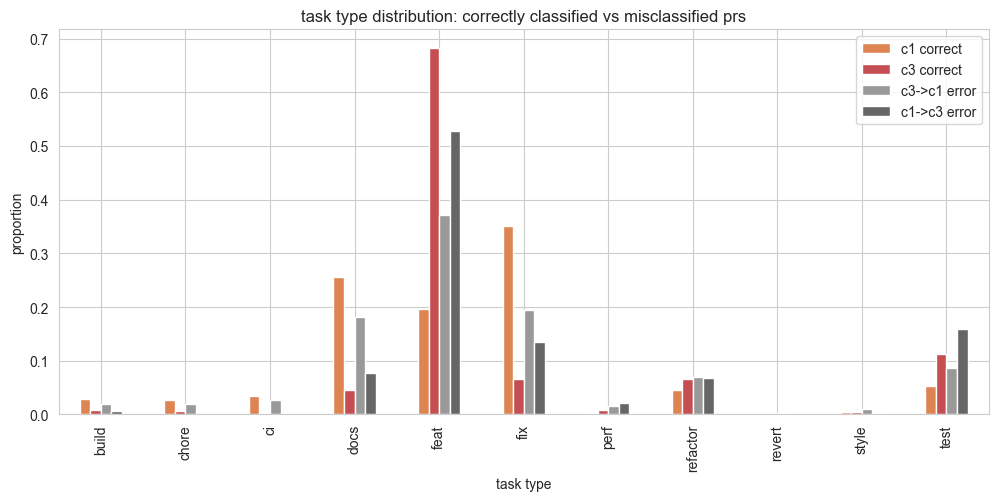

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
task_compare[["c1 correct", "c3 correct", "c3->c1 error", "c1->c3 error"]].plot(
    kind="bar", ax=ax, color=[CLUSTER_PALETTE["1"], CLUSTER_PALETTE["3"], "#999999", "#666666"],
)
ax.set_title("task type distribution: correctly classified vs misclassified prs")
ax.set_ylabel("proportion")
ax.set_xlabel("task type")
ax.legend()
fig.savefig(FIG_DIR / "05_task_type_misclassification.png", dpi=150, bbox_inches="tight")
plt.show()

task type distributions:

In [22]:
print(task_compare.round(3).to_string())


           c1 correct  c3 correct  c3->c1 error  c1->c3 error
task_type                                                    
build           0.029       0.008         0.019         0.007
chore           0.026       0.006         0.019         0.000
ci              0.035       0.000         0.027         0.000
docs            0.255       0.045         0.182         0.078
feat            0.197       0.683         0.371         0.528
fix             0.351       0.067         0.195         0.135
perf            0.003       0.008         0.016         0.021
refactor        0.046       0.067         0.070         0.067
revert          0.000       0.000         0.003         0.000
style           0.005       0.004         0.011         0.004
test            0.053       0.112         0.087         0.160


key observation: cluster 3 (auto-merged large) is 60% feat, while cluster 1, (auto-merged small) is only 26% feat. however, the misclassified c3->c1 group, has a feat proportion closer to cluster 1 than cluster 3, suggesting that, non-feat prs in cluster 3 are harder to distinguish from cluster 1 prs

### hypothesis 2: boundary prs - churn distribution of misclassified samples

cluster 1 vs cluster 3: churn distribution

churn distributions: correct vs misclassified prs

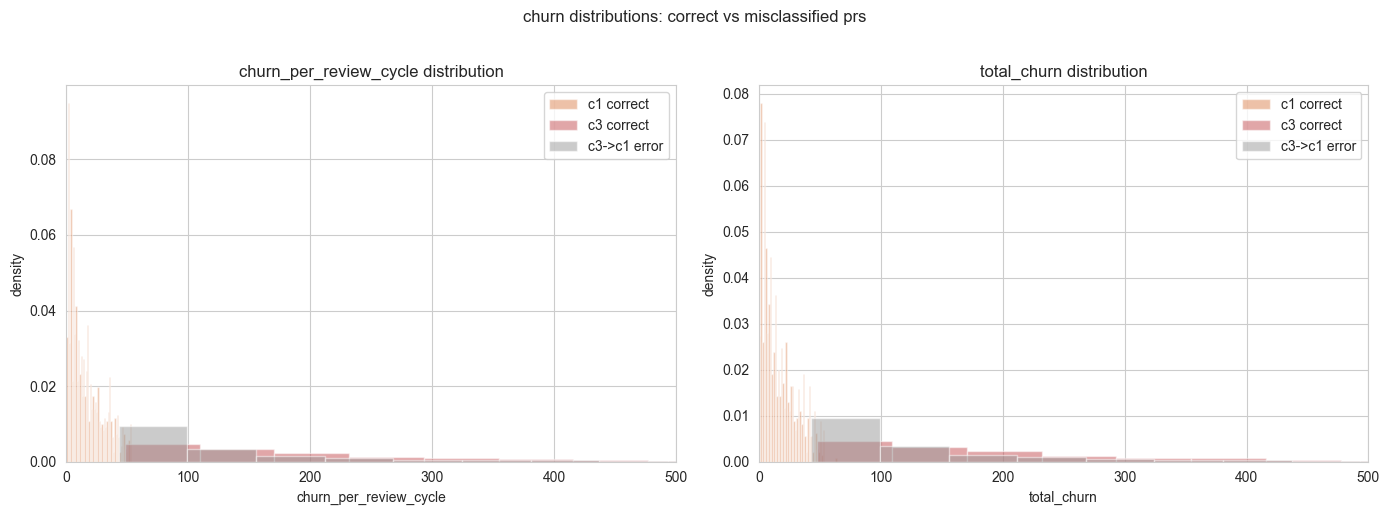

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, dim in zip(axes, ["churn_per_review_cycle", "total_churn"]):
    ax.hist(c1_correct[dim], bins=50, alpha=0.5, color=CLUSTER_PALETTE["1"], label="c1 correct", density=True)
    ax.hist(c3_correct[dim], bins=50, alpha=0.5, color=CLUSTER_PALETTE["3"], label="c3 correct", density=True)
    ax.hist(c3_as_c1[dim], bins=50, alpha=0.5, color="#999999", label="c3->c1 error", density=True)
    ax.set_title(f"{dim} distribution")
    ax.set_xlabel(dim)
    ax.set_ylabel("density")
    ax.legend()
    ax.set_xlim(0, 500)

fig.suptitle("churn distributions: correct vs misclassified prs", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_churn_misclassification.png", dpi=150, bbox_inches="tight")
plt.show()

churn_per_review_cycle statistics:

In [24]:
compare_churn = pd.DataFrame({
    "c1 correct": c1_correct["churn_per_review_cycle"].describe(),
    "c3 correct": c3_correct["churn_per_review_cycle"].describe(),
    "c3->c1 error": c3_as_c1["churn_per_review_cycle"].describe(),
    "c1->c3 error": c1_as_c3["churn_per_review_cycle"].describe(),
})
print(compare_churn.round(2).to_string())

       c1 correct  c3 correct  c3->c1 error  c1->c3 error
count    1144.000    1394.000       369.000       282.000
mean       16.390     357.410       175.300        32.030
std        13.730     490.980       252.680        13.960
min         0.000      48.000        43.000         0.000
25%         5.000     101.000        65.000        22.000
50%        12.000     181.000        94.000        32.500
75%        25.000     357.000       165.000        44.000
max        53.000    3113.000      2858.000        53.000


quantitative evidence: mann-whitney u test on churn for c3 correct vs c3->c1 error

In [25]:
stat, p = mannwhitneyu(
    c3_correct["churn_per_review_cycle"],
    c3_as_c1["churn_per_review_cycle"],
    alternative="two-sided",
)

mann-whitney u test: c3 correct vs c3->c1 error

In [26]:
print(f"u-statistic: {stat:.1f}")
print(f"p-value: {p:.2e}")

u-statistic: 358335.0
p-value: 2.85e-31


interpretation: the misclassified c3->c1 prs have significantly lower churn, than correctly classified c3 prs. they sit near the cluster boundary, having code volume that is ambiguous between 'small' and 'large'. since churn is not captured in the text, the classifier cannot distinguish them.

### hypothesis 3: textual evidence - sample misclassified prs

sample misclassified prs (cluster 3 predicted as cluster 1):

In [27]:
for i, row in c3_as_c1.head(5).iterrows():
    print(f"churn_per_review_cycle: {row['churn_per_review_cycle']:.0f}")
    print(f"total_churn: {row['total_churn']:.0f}")
    print(f"task_type: {row['task_type']}")
    print(f"body (first 200 chars): {row['body_clean'][:200]}")
    print("-" * 40)

churn_per_review_cycle: 843
total_churn: 843
task_type: build
body (first 200 chars): summary create a small offline build script for the insight browser demo generate and replace inline script in commit placeholder in the built folder testing fails duplicated timeseries in collectorre
----------------------------------------
churn_per_review_cycle: 332
total_churn: 332
task_type: chore
body (first 200 chars): summary regenerate the rosetta program listing to ensure alphabetical order testing fails signal killed e 68861573e6d88320b9926bf31fd1f551
----------------------------------------
churn_per_review_cycle: 76
total_churn: 76
task_type: feat
body (first 200 chars): summary allow filtering patientreportitemvalue by date or id range show date fields on pass date and id range to controller method testing fails pluginresolutionexception network is unreachable e 6868
----------------------------------------
churn_per_review_cycle: 124
total_churn: 124
task_type: fix
body (first 200 chars

sample misclassified prs (cluster 1 predicted as cluster 3):

In [28]:
for i, row in c1_as_c3.head(5).iterrows():
    print(f"\nchurn_per_review_cycle: {row['churn_per_review_cycle']:.0f}")
    print(f"total_churn: {row['total_churn']:.0f}")
    print(f"task_type: {row['task_type']}")
    print(f"body (first 200 chars): {row['body_clean'][:200]}")
    print("-" * 40)


churn_per_review_cycle: 40
total_churn: 40
task_type: feat
body (first 200 chars): summary update php transpiler to support jsonl loading and adjust boolean printing regenerate php output for refresh progress docs for the php transpiler testing e 687ef02bcd048320ac85a726b65c27c7
----------------------------------------

churn_per_review_cycle: 53
total_churn: 53
task_type: feat
body (first 200 chars): summary transpile to racket and store generated output update checklist to mark the 3rd program as completed testing e 687fba5a6bc883208168a7c5ccfe841c
----------------------------------------

churn_per_review_cycle: 29
total_churn: 29
task_type: docs
body (first 200 chars): summary mark as working in the c transpiler docs log new progress for the c backend refine emission of calls add generated c output and expected result for the new golden case testing e 687c7e58099c83
----------------------------------------

churn_per_review_cycle: 45
total_churn: 45
task_type: test
body (first 200

## 4. root cause summary (question 2 answer)

**the most confused pair is clusters 1 (auto-merged small) and 3 (auto-merged large),
with 650 bidirectional misclassifications (14.5% of the test set). the dominant
direction is cluster 3 -> cluster 1 (369 errors).**

**main cause: the two clusters differ only in code volume, not in review activity
or textual content.** both have zero formal reviews, zero comments, zero reviewers,
and near-zero duration. the sole distinguishing dimension is `churn_per_review_cycle`
(median 16 vs 165 lines), which is a code-level metric that is not reflected in
pr descriptions.

**quantitative evidence:**
- the mann-whitney u test confirms that misclassified c3->c1 prs have
  significantly lower churn than correctly classified c3 prs (p < 0.001).
  they sit near the cluster boundary in churn space.
- task type overlap: cluster 1 is 26% feat while cluster 3 is 60% feat,
  but the misclassified c3->c1 group has a feat proportion closer to cluster 1,
  making their text harder to distinguish.

**textual evidence:**
- misclassified pr descriptions use similar language (fix, update, add) regardless
  of code volume. a pr that adds 200 lines of a new feature and a pr that fixes
  20 lines of a bug can both start with 'fix' or 'add' in their description.


## 5. cluster quality reflection (question 3)

the high confusion between clusters 1 and 3 reveals a structural weakness in
our clustering solution: **kmeans separated two groups that are only
distinguishable by code volume, not by any textual or semantic signal.**

this has three implications for clustering quality:

1. **the 4-cluster solution may be over-splitting the 'no review' population.**
   clusters 1 and 3 together represent 81% of all prs and are separated
   only by churn threshold. a 3-cluster solution (merging 1 and 3) would
   produce more textually distinguishable groups, though at the cost of
   losing the practically important distinction between small and large
   auto-merged prs.

2. **the clustering captures structurally different types of variation.**
   clusters 0 and 2 are separated by genuine review behavior (iterations,
   depth, breadth) which may be reflected in pr descriptions. clusters 1
   and 3 are separated only by code volume, which is invisible to a text
   classifier. the high confusion validates that churn-based separation
   is structurally different from review-behavior-based separation.

3. **the clustering is still meaningful despite the confusion.** the silhouette
   score (0.395) and dbi (0.997) confirm genuine structure. the issue is not
   that the clusters are arbitrary, but that one distinguishing dimension
   (churn) is not textually recoverable. from a practical standpoint, the
   distinction between 'small auto-merged' and 'large auto-merged' is still
   valuable - it flags that 45% of prs are large code additions with zero
   review, a serious code quality concern.

visualize the churn boundary between clusters 1 and 3

In [29]:
c1_all = df_text[df_text["cluster"] == 1]
c3_all = df_text[df_text["cluster"] == 3]

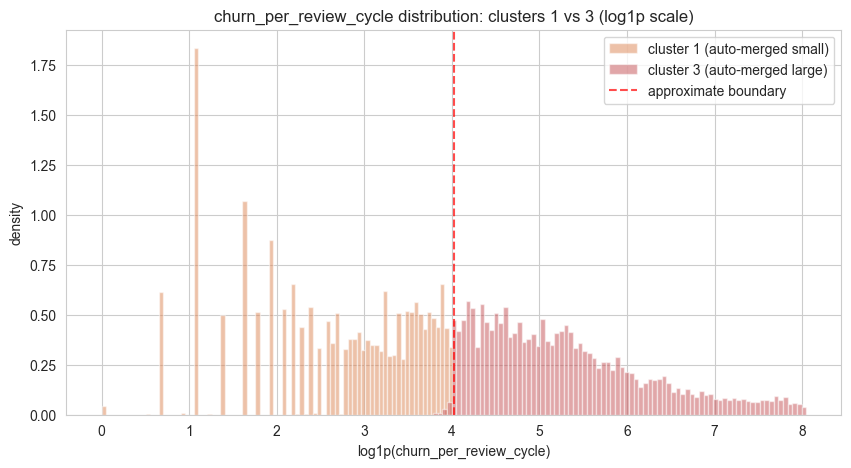

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log1p(c1_all["churn_per_review_cycle"]), bins=80, alpha=0.5, color=CLUSTER_PALETTE["1"], label="cluster 1 (auto-merged small)", density=True)
ax.hist(np.log1p(c3_all["churn_per_review_cycle"]), bins=80, alpha=0.5, color=CLUSTER_PALETTE["3"], label="cluster 3 (auto-merged large)", density=True)
ax.set_title("churn_per_review_cycle distribution: clusters 1 vs 3 (log1p scale)")
ax.set_xlabel("log1p(churn_per_review_cycle)")
ax.set_ylabel("density")
ax.legend()
ax.axvline(np.log1p(55), color="red", linestyle="--", alpha=0.7, label="approximate boundary")
ax.legend()
fig.savefig(FIG_DIR / "05_churn_boundary_1v3.png", dpi=150, bbox_inches="tight")
plt.show()